# Entrenamiento por Minimización de Gradiente
## Regresión Lineal sin librerías de Machine Learning

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Definir los datos
X = np.array([
    [1, 2],
    [2, 1],
    [3, 4],
    [4, 3],
    [5, 5]
])

y = np.array([5, 5, 11, 11, 15])

In [2]:
# Parámetros del modelo
w = np.zeros(2)  # Pesos para cada característica
b = 0.0          # Sesgo
alpha = 0.01     # Learning rate
epochs = 1000
loss_history = []

# Funciones
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def predict(X, w, b):
    return X @ w + b

In [3]:
# Entrenamiento
for epoch in range(epochs):
    y_pred = predict(X, w, b)
    error = y_pred - y
    dw = (2/len(X)) * (X.T @ error)
    db = (2/len(X)) * np.sum(error)
    w -= alpha * dw
    b -= alpha * db
    loss_history.append(mse(y, y_pred))
    
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}/{epochs} - MSE: {loss_history[-1]:.6f}")

print(f"\nEntrenamiento completado!")
print(f"w = {w}, b = {b:.4f}")

Epoch 100/1000 - MSE: 0.026627
Epoch 200/1000 - MSE: 0.022431
Epoch 300/1000 - MSE: 0.020225
Epoch 400/1000 - MSE: 0.019064
Epoch 500/1000 - MSE: 0.018454
Epoch 600/1000 - MSE: 0.018134
Epoch 700/1000 - MSE: 0.017965
Epoch 800/1000 - MSE: 0.017876
Epoch 900/1000 - MSE: 0.017830
Epoch 1000/1000 - MSE: 0.017805

Entrenamiento completado!
w = [1.44622609 1.44622609], b = 0.7206


In [4]:
# Predicciones
y_pred = predict(X, w, b)

print("\n" + "=" * 50)
print("PARÁMETROS APRENDIDOS")
print("=" * 50)
print(f"w = {w}")
print(f"b = {b:.4f}")
print(f"\nEcuación: y = {w[0]:.6f}*x1 + {w[1]:.6f}*x2 + {b:.6f}")

print("\n" + "=" * 50)
print("PREDICCIONES")
print("=" * 50)
print(f"{'x1':<6} {'x2':<6} {'y_real':<8} {'y_pred':<8} {'error':<8}")
print("-" * 40)
for i in range(len(X)):
    print(f"{X[i,0]:<6} {X[i,1]:<6} {y[i]:<8} {y_pred[i]:<8.4f} {y[i]-y_pred[i]:<8.4f}")

mse_final = mse(y, y_pred)
print(f"\nMSE final: {mse_final:.6f}")


PARÁMETROS APRENDIDOS
w = [1.44622609 1.44622609]
b = 0.7206

Ecuación: y = 1.446226*x1 + 1.446226*x2 + 0.720601

PREDICCIONES
x1     x2     y_real   y_pred   error   
----------------------------------------
1      2      5        5.0593   -0.0593 
2      1      5        5.0593   -0.0593 
3      4      11       10.8442  0.1558  
4      3      11       10.8442  0.1558  
5      5      15       15.1829  -0.1829 

MSE final: 0.017805


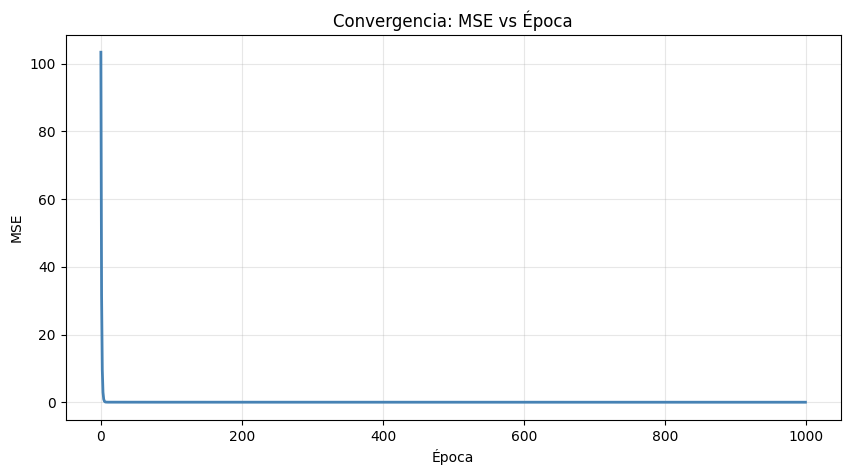

MSE inicial: 103.400000
MSE final: 0.017805


In [5]:
# Visualizar la pérdida
plt.figure(figsize=(10, 5))
plt.plot(loss_history, linewidth=2, color='steelblue')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.title('Convergencia: MSE vs Época')
plt.grid(True, alpha=0.3)
plt.show()

print(f"MSE inicial: {loss_history[0]:.6f}")
print(f"MSE final: {loss_history[-1]:.6f}")

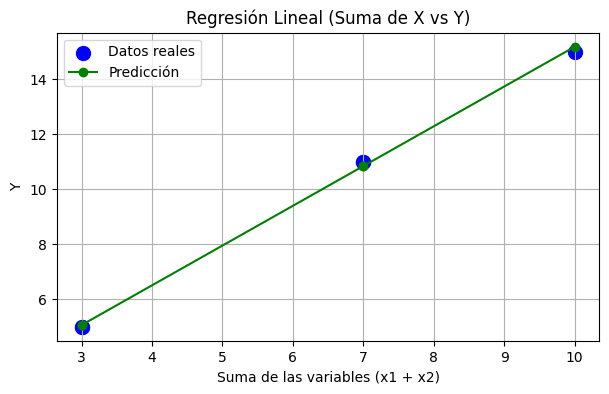

In [ ]:
X_sum = np.sum(X, axis=1) 
y_final_pred = predict(X, w, b)

plt.figure(figsize=(7, 4))
plt.scatter(X_sum, y, color='blue', label='Datos reales', s=100)
plt.plot(X_sum, y_final_pred, color='green', marker='o', label='Predicción')
plt.title('Regresión Lineal (Suma de X vs Y)')
plt.xlabel('Suma de las variables (x1 + x2)')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()